# EXPLORATORY DATA ANALYSIS (EDA)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

orders = pd.read_csv('./clean_datasets/orders_clean.csv', parse_dates=[
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

items = pd.read_csv('./clean_datasets/items_clean.csv', parse_dates=[
    'shipping_limit_date'
])

reviews = pd.read_csv('./clean_datasets/reviews_clean.csv', parse_dates=[
    'review_creation_date',
    'review_answer_timestamp'
])

products  = pd.read_csv('./clean_datasets/products_clean.csv')
customers = pd.read_csv('./clean_datasets/customers_clean.csv')
payments  = pd.read_csv('./clean_datasets/payments_clean.csv')
sellers   = pd.read_csv('./clean_datasets/sellers_clean.csv')
geoloc    = pd.read_csv('./clean_datasets/geoloc_agg.csv')

### Temporal Analysis

In [2]:
# Filter only delivered orders wiht valid dates
orders_delivered = orders[
    (orders['order_status'] == 'delivered') &
    (orders['has_invalid_dates'].eq(False))
].copy()

# Extract time features
orders_delivered['year_month'] = orders_delivered['order_purchase_timestamp'].dt.to_period('M')
orders_delivered['month'] = orders_delivered['order_purchase_timestamp'].dt.month
orders_delivered['day_of_week'] = orders_delivered['order_purchase_timestamp'].dt.day_of_week
orders_delivered['hour'] = orders_delivered['order_purchase_timestamp'].dt.hour

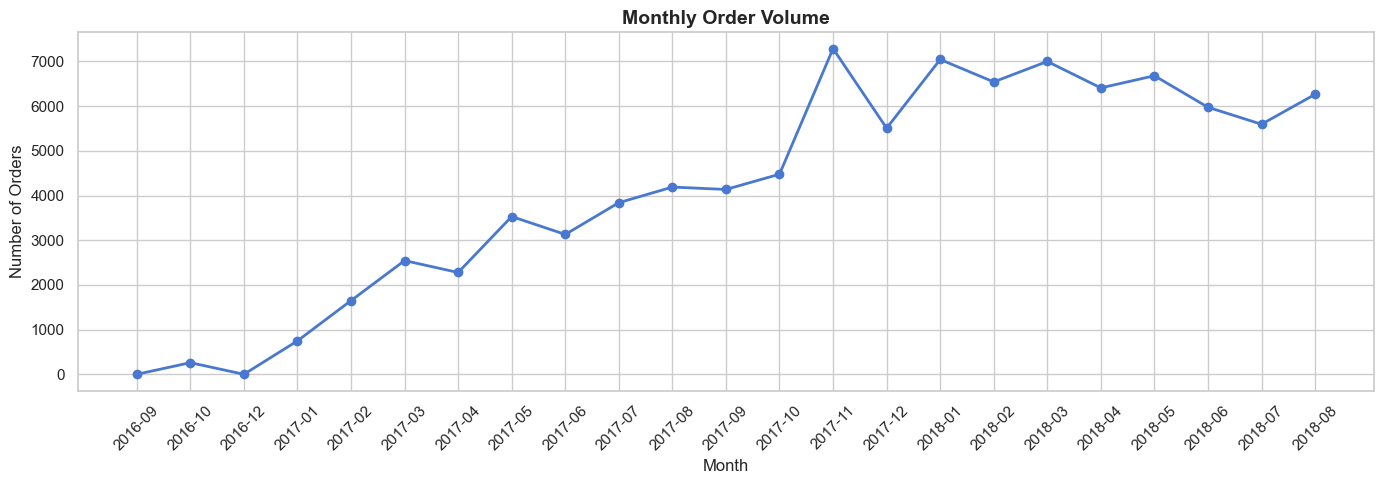

In [3]:
monthly_orders = orders_delivered.groupby('year_month').size().reset_index(name='order_count')
monthly_orders['year_month_str'] = monthly_orders['year_month'].astype(str)

# Line chart - orders per month
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_orders['year_month_str'], monthly_orders['order_count'], marker='o', linewidth=2)
ax.set_title('Monthly Order Volume', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

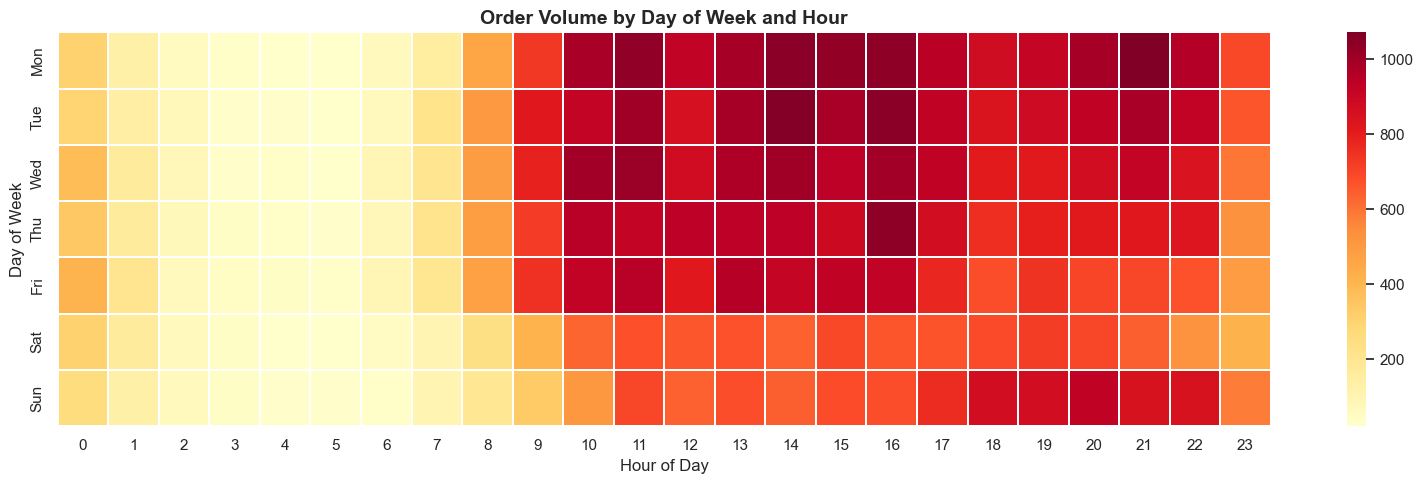

In [4]:
heatmap_data = orders_delivered.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
heatmap_data.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Heatmap day of the week x hour
fig, ax = plt.subplots(figsize=(16,5))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, linewidths=0.3)
ax.set_title('Order Volume by Day of Week and Hour', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.show()

**Key Findings:**
- Order volume grew consistently from late 2016, peaking in November 2017 (likely Black Friday)
- A sharp drop in December 2017 was followed by stabilization through 2018
- Orders concentrate between 8am–11pm on weekdays; weekends show noticeably lower activity

### Geographic Analysis

In [5]:
# Orders per state via customers
orders_customers = orders_delivered.merge(
    customers[['customer_id', 'customer_state', 'customer_zip_code_prefix']],
    on='customer_id',
    how='left'
    )

orders_by_state = orders_customers.groupby('customer_state').size().reset_index(name='order_count').sort_values('order_count', ascending=False)

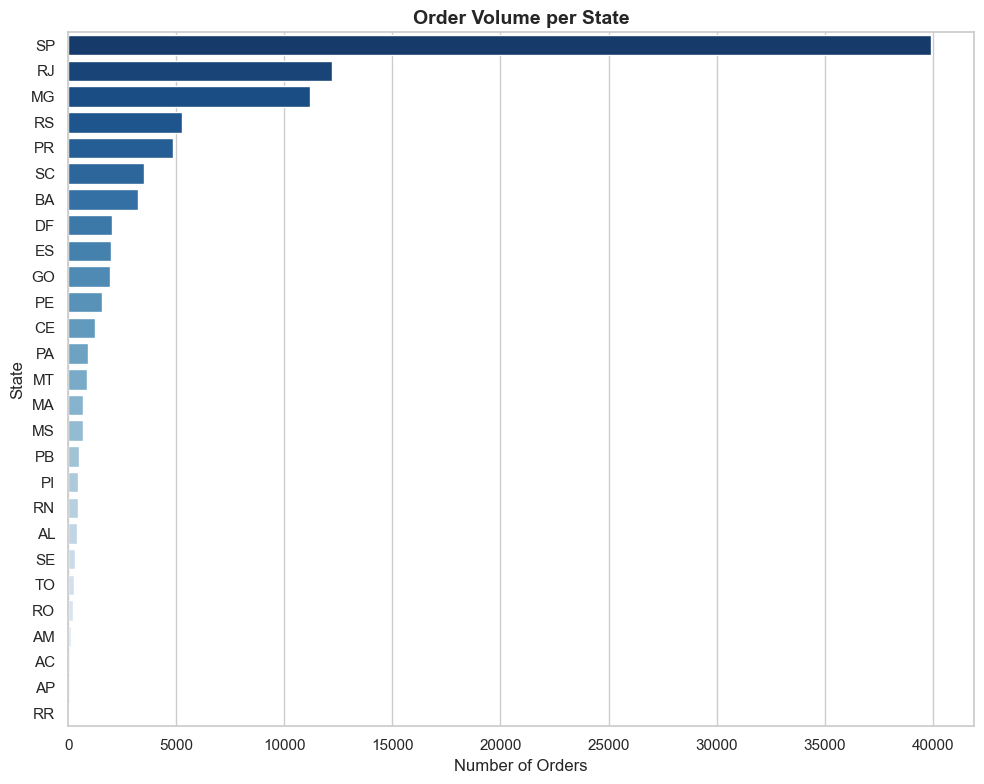

In [6]:
fig, ax = plt.subplots(figsize=(10,8))
sns.barplot(data=orders_by_state, y='customer_state', x='order_count', ax=ax, hue='customer_state', palette='Blues_r', legend=False)
ax.set_title('Order Volume per State', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Orders')
ax.set_ylabel('State')
plt.tight_layout()
plt.show()

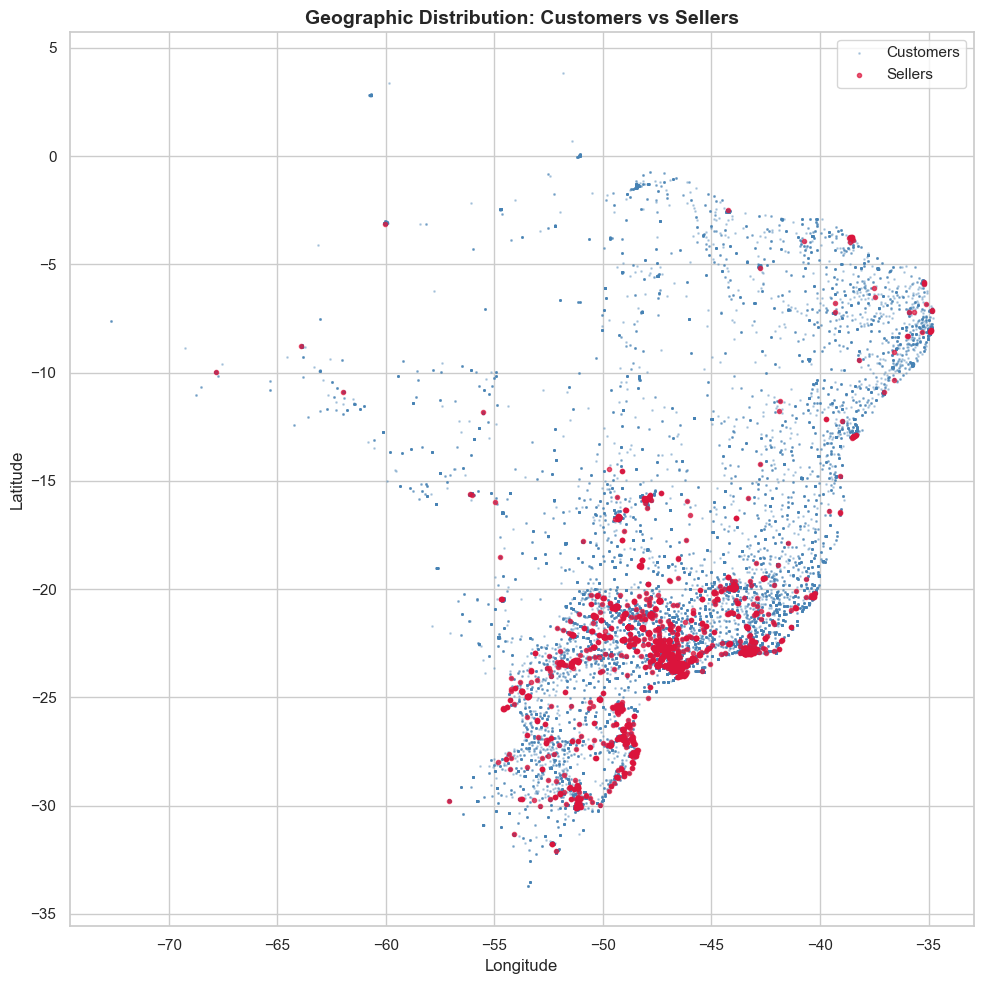

In [7]:
# Scatter Plot customers vs sellers

customers_geo = customers.merge(
    geoloc[['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']],
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='inner'
)

sellers_geo = sellers.merge(
    geoloc[['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']],
    left_on='seller_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='inner'
)

fig, ax = plt.subplots(figsize=(10,10))
ax.scatter(customers_geo['geolocation_lng'], customers_geo['geolocation_lat'], s=1, alpha=0.3, color='steelblue', label='Customers')
ax.scatter(sellers_geo['geolocation_lng'], sellers_geo['geolocation_lat'], s=9, alpha=0.7, color='crimson', label='Sellers')
ax.set_title('Geographic Distribution: Customers vs Sellers', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
plt.tight_layout()
plt.show()

**Key Findings:**
- São Paulo (SP) dominates with ~40k orders, followed by RJ and MG at a significant distance
- Sellers are heavily concentrated in the southeast (SP/RJ), while customers are spread nationwide

### Operational Analysis

In [8]:
orders_op = orders_delivered.copy()

orders_op['delivery_days'] =(
    orders_op['order_delivered_customer_date'] - orders_op['order_purchase_timestamp']
).dt.days

orders_op['days_vs_estimate'] = (
    orders_op['order_delivered_customer_date'] - orders_op['order_estimated_delivery_date']
).dt.days

# Positive = late, Negative = early
orders_op['delivered_late'] = orders_op['days_vs_estimate'] > 0

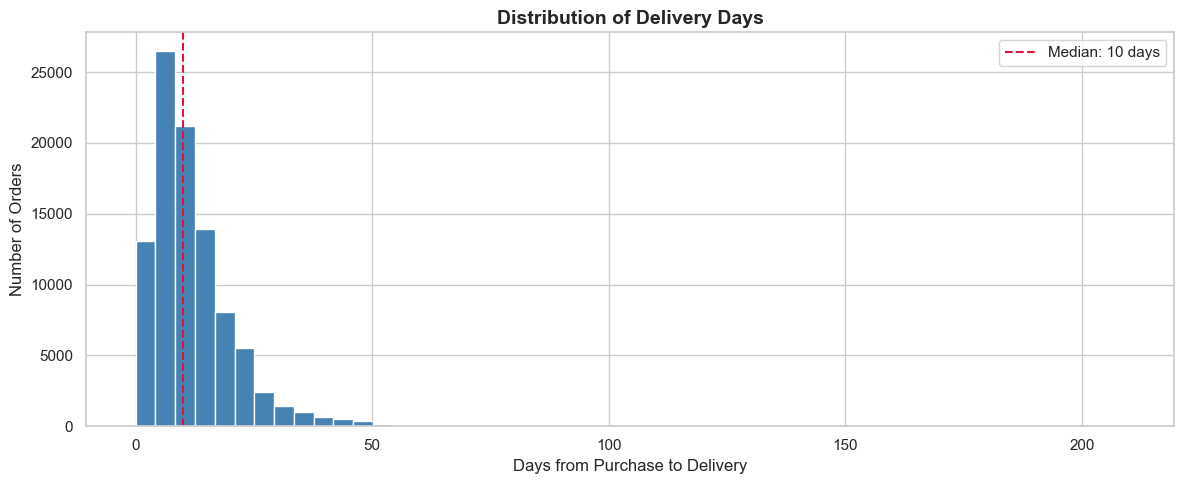

In [9]:
# Delivery Days Histogram
fig, ax = plt.subplots(figsize=(12,5))
ax.hist(orders_op['delivery_days'].dropna(), bins=50, color='steelblue', edgecolor='white')
ax.set_title('Distribution of Delivery Days', fontsize=14, fontweight='bold')
ax.set_xlabel('Days from Purchase to Delivery')
ax.set_ylabel('Number of Orders')
ax.axvline(orders_op['delivery_days'].median(), color='crimson', linestyle='--', label=f'Median: {orders_op['delivery_days'].median():.0f} days')
ax.legend()
plt.tight_layout()
plt.show()

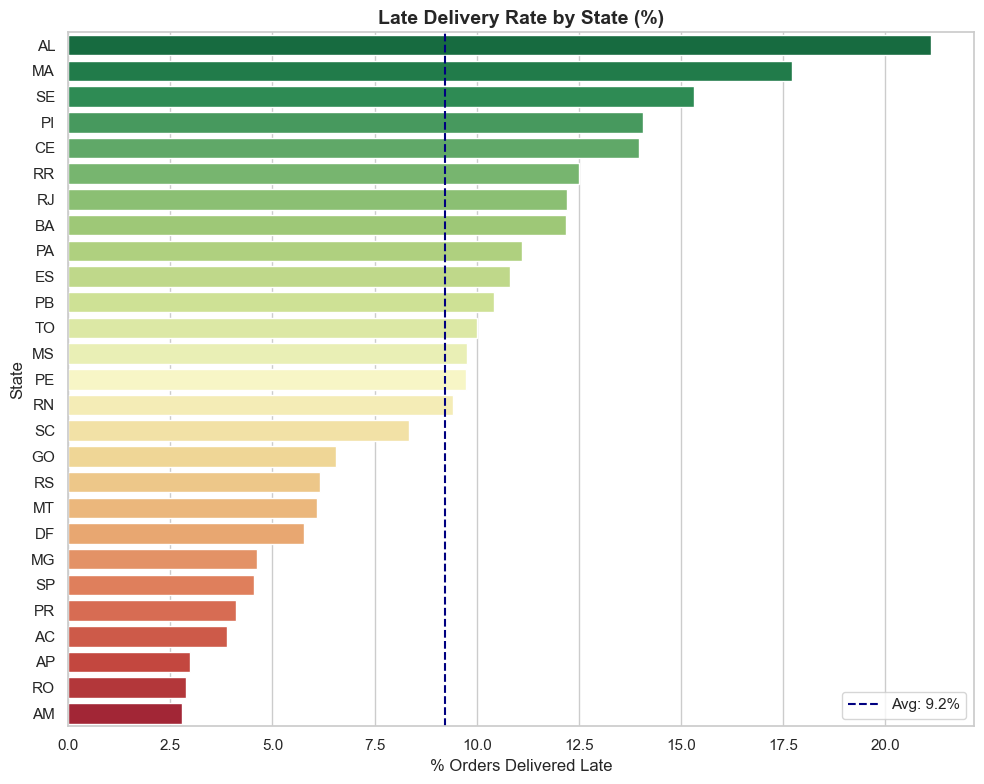

In [10]:
# Percentage punctual deliveries vs late deliveries
orders_op_state = orders_op.merge(
    customers[['customer_id', 'customer_state']],
    on='customer_id',
    how='left'
)

on_time_by_state = (
    orders_op_state.groupby('customer_state')['delivered_late']
    .mean()
    .mul(100)
    .reset_index(name='pct_late')
    .sort_values('pct_late', ascending=False)
)

fig, ax = plt.subplots(figsize=(10,8))
sns.barplot(
    data=on_time_by_state,
    y='customer_state',
    x='pct_late',
    ax=ax,
    hue='customer_state',
    palette='RdYlGn_r',
    legend=False
)
ax.set_title('Late Delivery Rate by State (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('% Orders Delivered Late')
ax.set_ylabel('State')
ax.axvline(on_time_by_state['pct_late'].mean(), color='navy', linestyle='--', label=f'Avg: {on_time_by_state['pct_late'].mean():.1f}%')
ax.legend()
plt.tight_layout()
plt.show()

**Key Findings:**
- Median delivery time is around 10 days, with a right-skewed distribution indicating occasional extreme delays
- Average late delivery rate is 9.2% nationally
- SP itself has only ~4.5% late rate, confirming proximity to sellers improves fulfillment

### Product Analysis

In [11]:
items_products = items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'    
)

items_products['revenue'] = items_products['price'] + items_products['freight_value']

category_stats = items_products.groupby('product_category_name').agg(
    total_orders = ('order_id', 'count'),
    total_revenue = ('revenue', 'sum')
).reset_index()

top15_volume = category_stats.sort_values('total_orders', ascending=False).head(15)
top15_revenue = category_stats.sort_values('total_revenue', ascending=False).head(15)

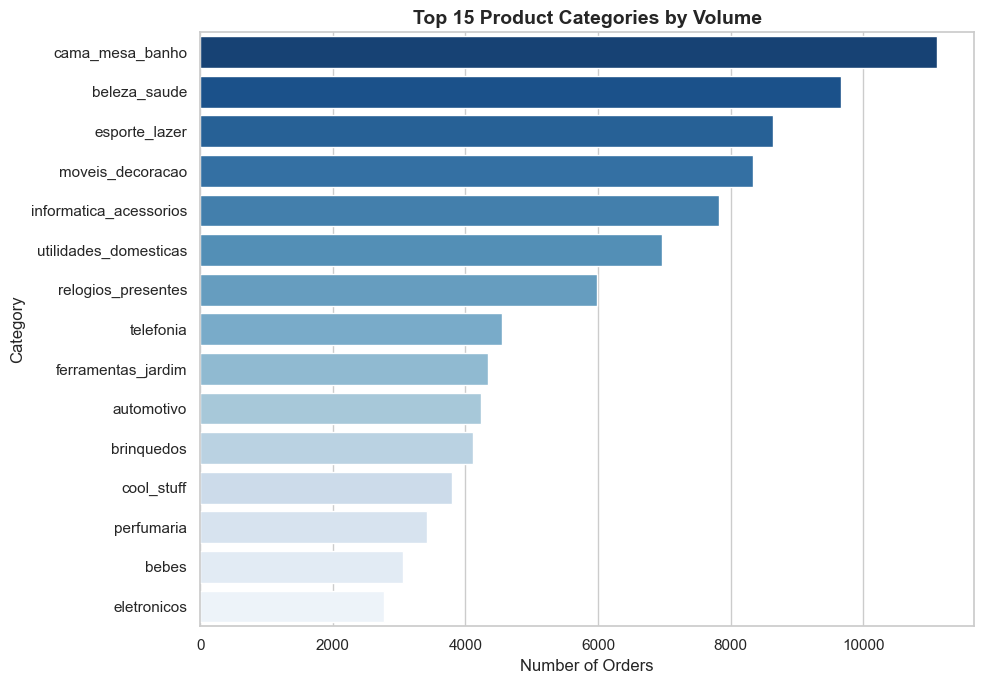

In [12]:
# Barplot top 15 categories per volume
fig, ax = plt.subplots(figsize=(10,7))
sns.barplot(
    data=top15_volume,
    y='product_category_name',
    x='total_orders',
    ax=ax,
    hue='product_category_name',
    palette='Blues_r',
    legend=False
)
ax.set_title('Top 15 Product Categories by Volume', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Orders')
ax.set_ylabel('Category')
plt.tight_layout()
plt.show()

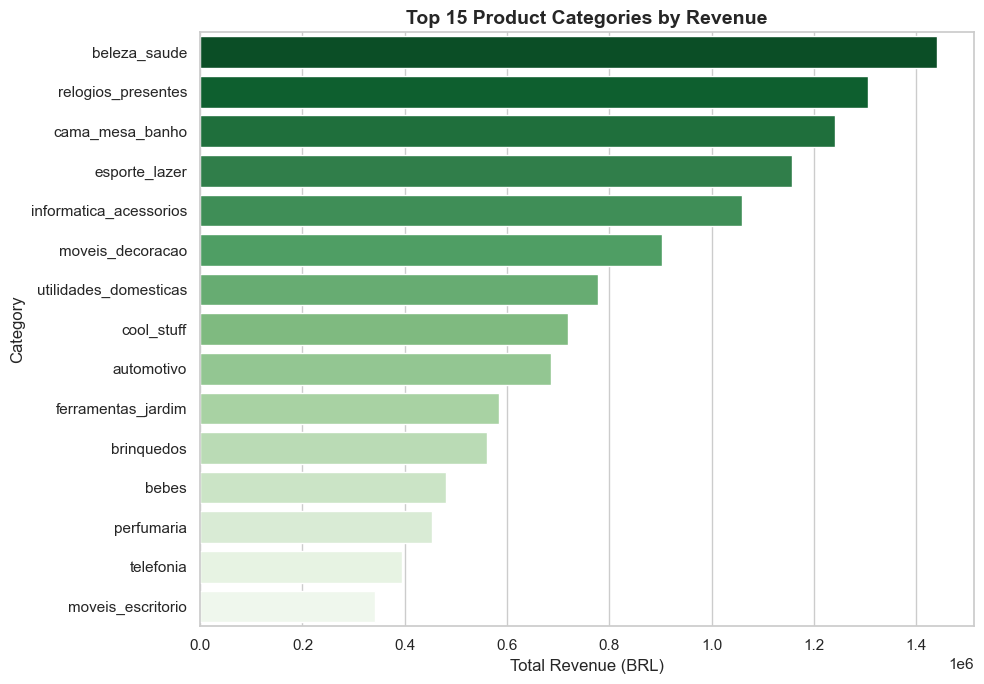

In [13]:
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    data=top15_revenue,
    y='product_category_name',
    x='total_revenue',
    ax=ax,
    hue='product_category_name',
    palette='Greens_r',
    legend=False
)
ax.set_title('Top 15 Product Categories by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue (BRL)')
ax.set_ylabel('Category')
plt.tight_layout()
plt.show()

**Key Findings:**
- cama_mesa_banho leads in volume but beleza_saude leads in revenue, indicating a higher average ticket
- relogios_presentes is #7 in volume but #2 in revenue — the highest average ticket in the top 15
- telefonia shows the opposite pattern: high volume, low revenue — low-priced products

### Payment Analysis

In [14]:
# Payment Type Distribution
payment_type_dist = payments.groupby('payment_type').size().reset_index(name='count').sort_values('count', ascending=False)

# Installmentes Distribution
installments = payments[payments['payment_type'] == 'credit_card']['payment_installments'].value_counts().sort_index().reset_index()
installments.columns = ['installments', 'count']

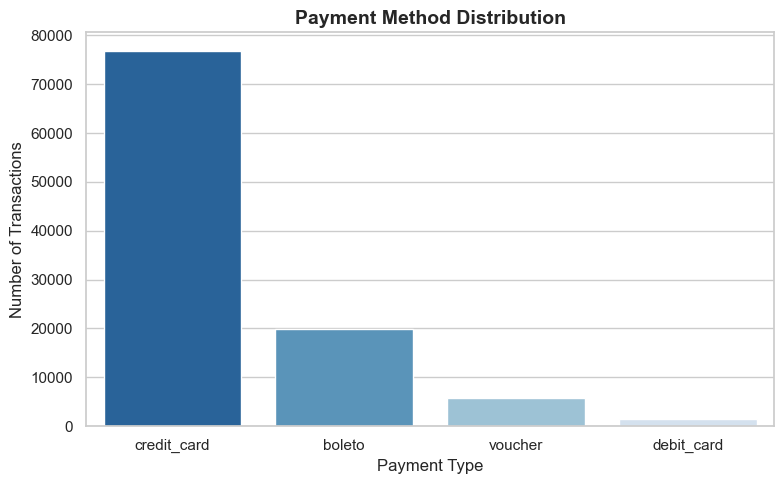

In [15]:
# Bar chart payment methods

fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(
    data=payment_type_dist,
    x='payment_type',
    y='count',
    ax=ax,
    hue='payment_type',
    palette='Blues_r',
    legend=False
)
ax.set_title('Payment Method Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Payment Type')
ax.set_ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

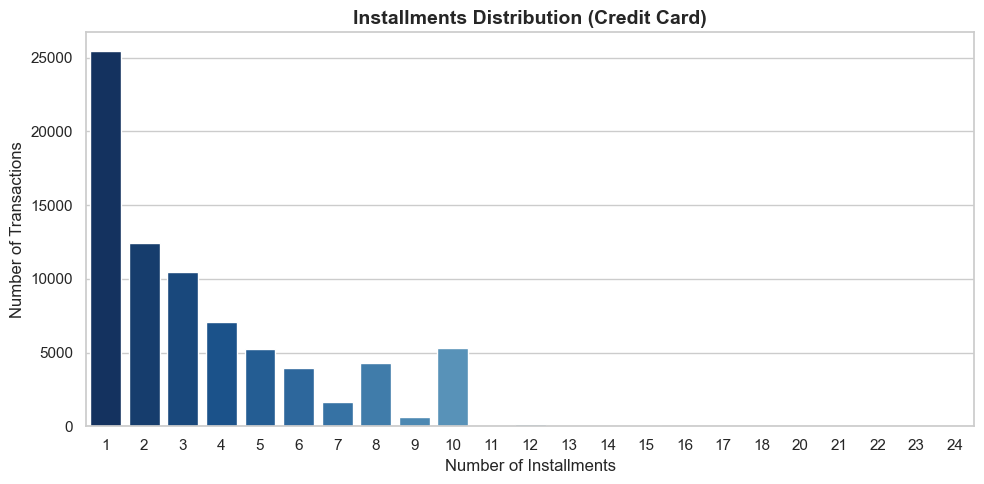

In [16]:
# Installments Histogram (credit card)
fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(
    data=installments,
x='installments',
y='count',
ax=ax,
hue='installments',
palette='Blues_r',
legend=False
)
ax.set_title('Installments Distribution (Credit Card)', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Installments')
ax.set_ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

**Key Findings:**
- Credit card dominates; boleto bancário is a distant second, reflecting Brazilian payment culture
- Most credit card purchases are paid in 1 installment (~25k), but 10 installments shows a notable spike

### Satisfaction Analysis

In [19]:
reviews_orders = reviews.merge(
    orders_op[['order_id', 'delivery_days', 'days_vs_estimate']],
    on='order_id',
    how='inner'
)

score_dist = reviews['review_score'].value_counts().sort_index().reset_index()
score_dist.columns = ['score', 'count']

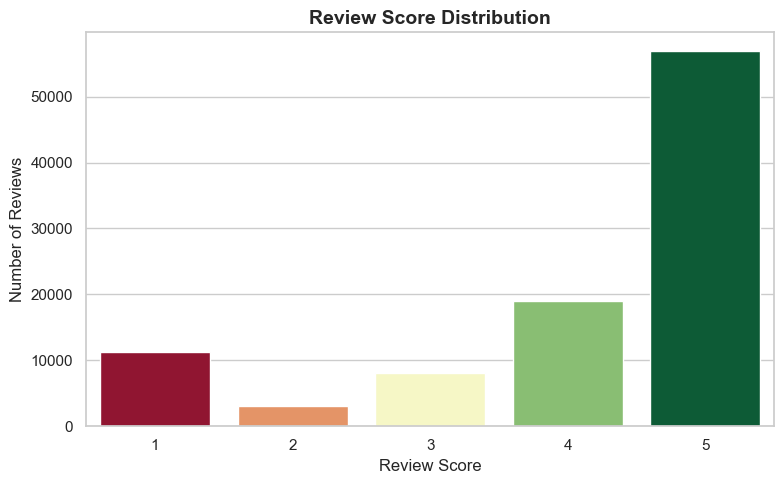

In [20]:
# Scores Distribution

fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(
    data=score_dist,
    x='score',
    y='count',
    ax=ax,
    hue='score',
    palette='RdYlGn',
    legend=False
)
ax.set_title('Review Score Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Review Score')
ax.set_ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

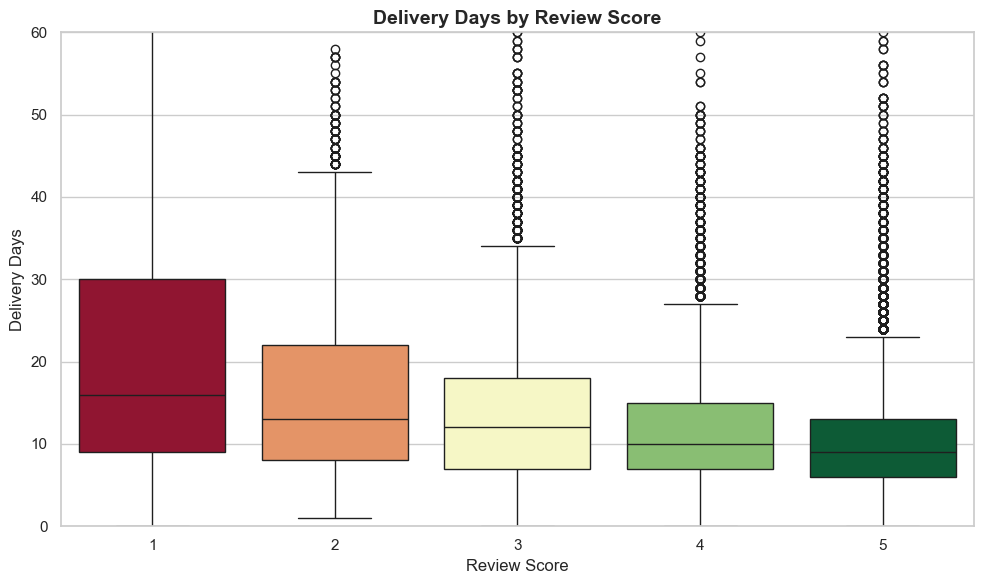

In [ ]:
# Boxplot Score vs delivery days
fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot(
    data=reviews_orders.dropna(subset=['delivery_days']),
    x='review_score',
    y='delivery_days',
    ax=ax,
    hue='review_score',
    palette='RdYlGn',
    legend=False
)
ax.set_title('Delivery Days by Review Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Review Score')
ax.set_ylabel('Delivery Days')
ax.set_ylim(0, 60)
plt.tight_layout()
plt.show()

**Key Findings:**
- Score 5 dominates (~56k reviews); score 1 (~11k) outranks scores 2 and 3 — dissatisfied customers review more
- Clear negative correlation between delivery days and review score
- Score 1 orders have a median of ~16 delivery days; score 5 orders median is ~10 days
- Delivery time is a primary driver of customer satisfaction in this dataset